<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/Decsion_Tree_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [54]:
Pokemon = pd.read_csv("/content/Pokemon.csv")
diabetes = pd.read_csv("/content/diabetes.csv")

In [61]:
Pokemon

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [59]:
higest=Pokemon["Defense"].max()
count=(Pokemon["Defense"]==higest).sum()
count

np.int64(3)

In [60]:
Pokemon[["Generation", "Speed", "Attack"]].corr()

,Generation,Speed,Attack
Generation,1.000000,-0.023121,0.051451
Speed,-0.023121,1.000000,0.381240
Attack,0.051451,0.381240,1.000000


In [56]:
count=(Pokemon[Pokemon["Generation"]==5].shape[0])

In [57]:
count

165

In [30]:
Pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [31]:
Pokemon.shape

(800, 13)

In [32]:
(386/800)*100

48.25

In [62]:
Pokemon.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,386
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


In [63]:
Pokemon["Type 2"] = Pokemon["Type 2"].fillna("None")

In [64]:
print(Pokemon.isnull().sum())

#             0
Name          0
Type 1        0
Type 2        0
Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [67]:
le=LabelEncoder()
col=["Legendary"]
for i in col:
  Pokemon[i]=le.fit_transform(Pokemon[i])

In [68]:
x=Pokemon.drop(["Legendary","Name"] ,axis=1)
y=Pokemon["Legendary"]

In [74]:
y=y.astype("int")

In [75]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

In [76]:
from sklearn.tree import DecisionTreeClassifier

In [77]:
model = DecisionTreeClassifier()
model.fit(x_train,y_train)

ValueError: could not convert string to float: 'Electric'

In [34]:

for i in Pokemon.columns:
  if(Pokemon[i].dtype == "object"):
    Pokemon[i]= Pokemon[i].fillna(Pokemon[i].mode()[0])


In [35]:
Pokemon.replace([" ","?"],np.nan,inplace=True)

In [36]:
Pokemon.isnull().sum().sum()

np.int64(0)

In [37]:
Pokemon.duplicated().sum()

np.int64(0)

In [40]:
# for i in Pokemon.columns:
#   if(Pokemon[i].dtype!="object"):
#     plt.boxplot(Pokemon[i])
#     plt.title(i)
#     plt.show()

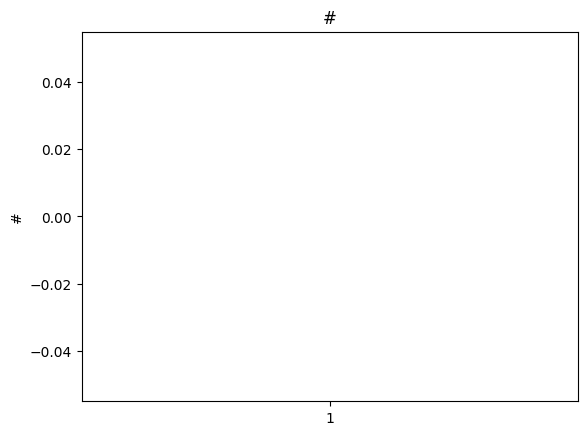

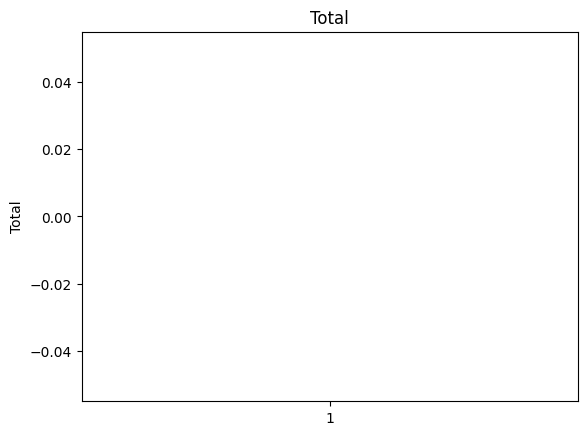

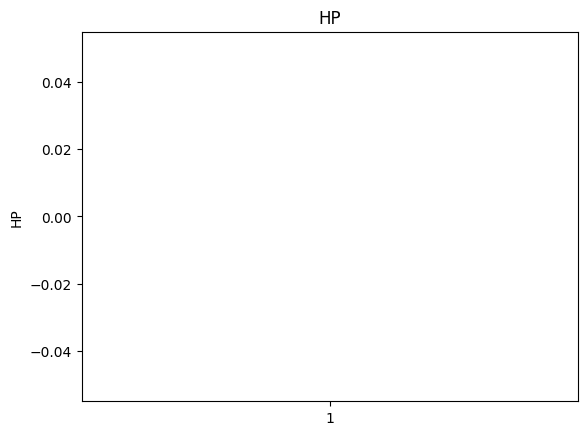

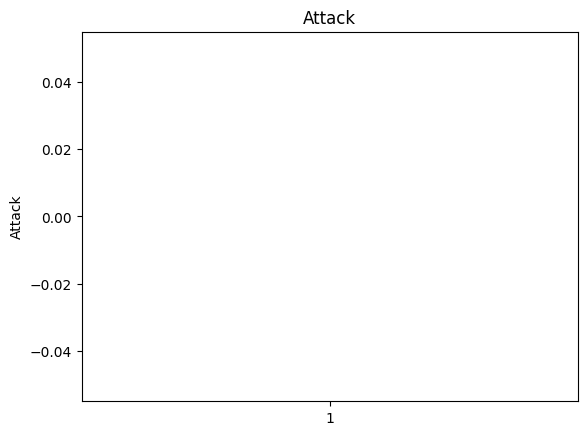

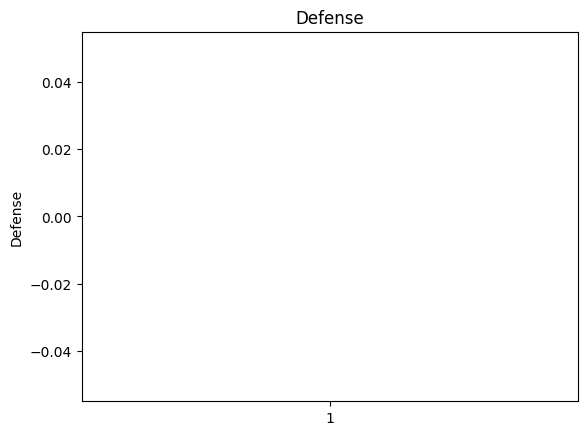

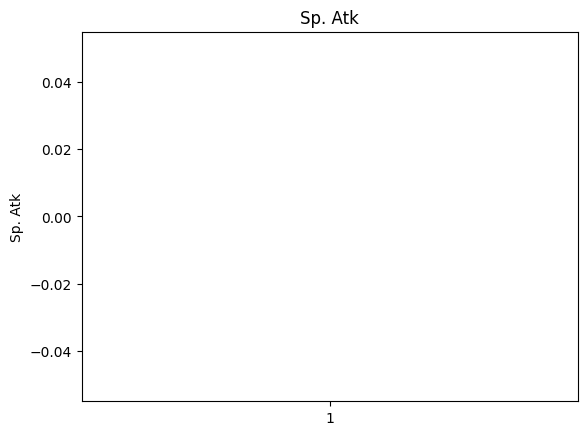

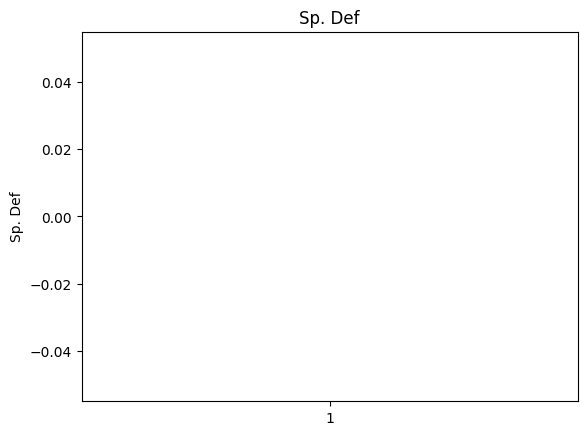

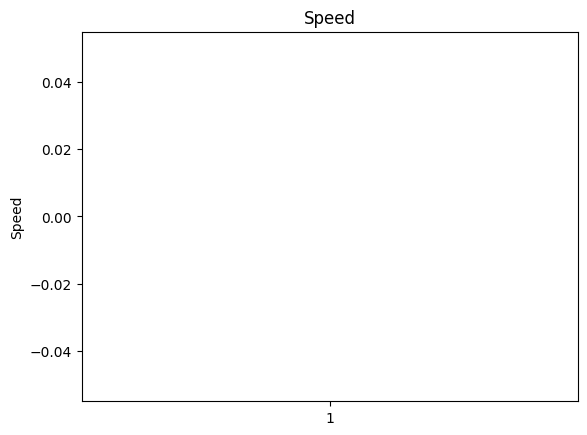

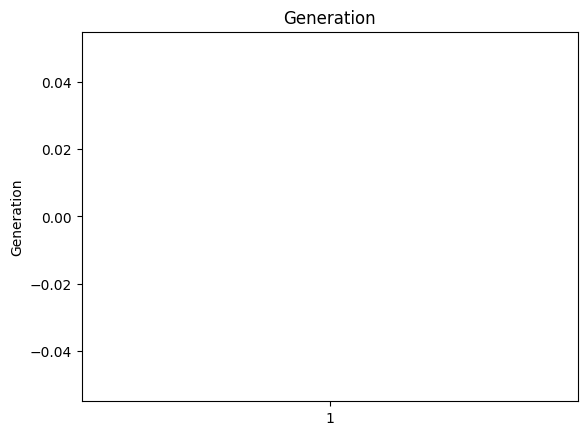

In [41]:
numeric_cols = Pokemon.select_dtypes(include="number").columns

for i in numeric_cols:
    plt.boxplot(Pokemon[i].dropna())
    plt.title(i)
    plt.ylabel(i)
    plt.show()

In [50]:
Pokemon.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

In [51]:
col =["HP","Attack","Defense","Sp. Atk","Sp. Def","Speed",]

In [52]:
for i in col:
  Q1 = Pokemon[i].quantile(0.25)
  Q3 = Pokemon[i].quantile(0.75)

  IQR =Q3-Q1
  LB= Q1-1.5*IQR
  UB=Q3+15*IQR
  Pokemon = Pokemon[(Pokemon[i]>=LB) &(Pokemon[i]<=UB)]

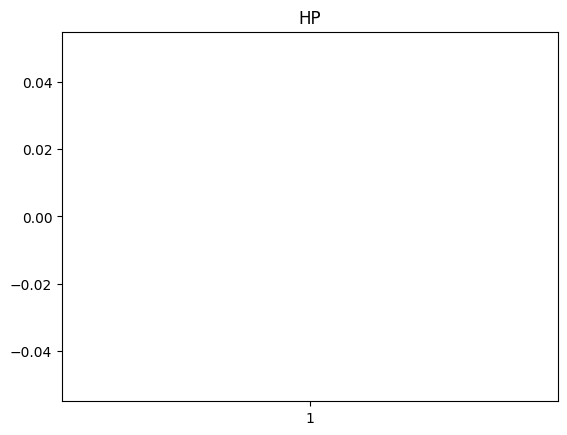

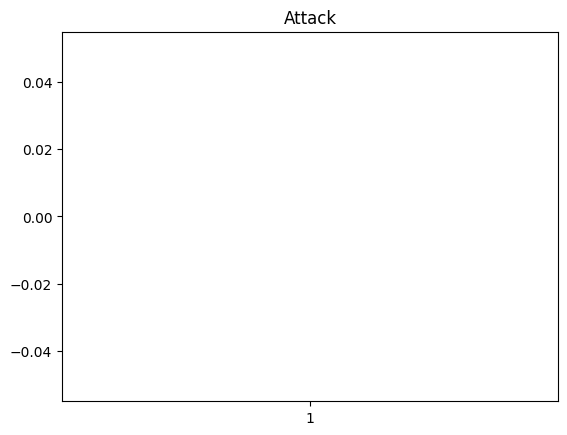

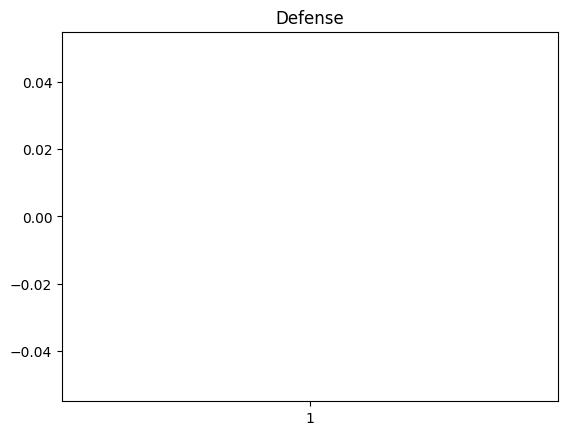

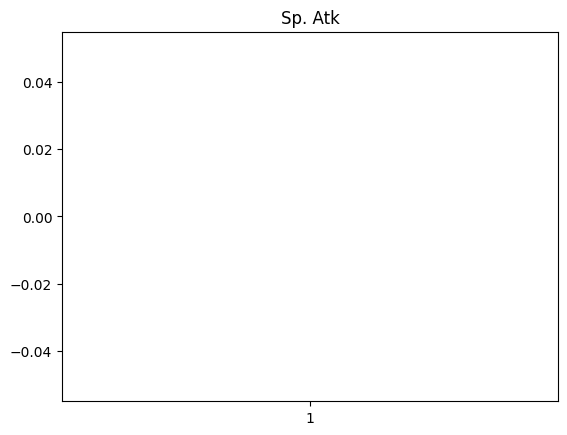

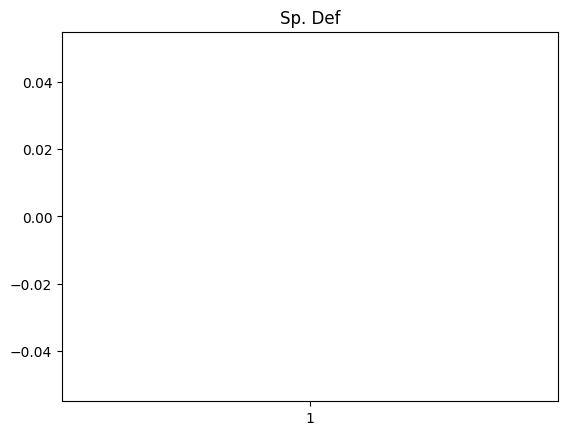

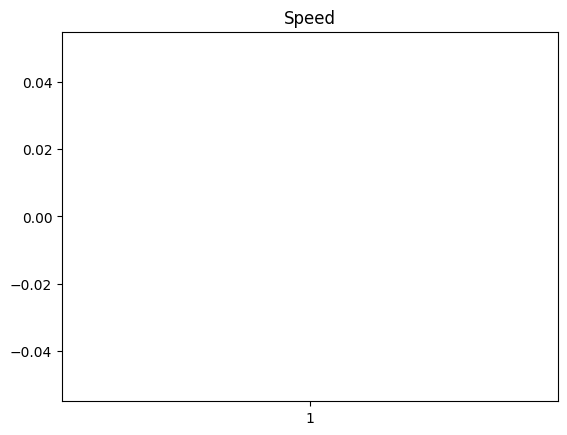

In [53]:
for i in col:
  plt.boxplot(Pokemon[i])
  plt.title(i)
  plt.show()